# 1. Aufgabenstellung: Anomalieerkennung – Sales Data

1. **Trainingsphase**:
Verwende ausschließlich normale Verkaufsdaten (Sales Data), um ein Modell zu trainieren, das typische Muster und Wertebereiche (z. B. für Betrag, Steuern, Zahlungsbedingungen usw.) lernt.

3. **Vorhersagephase**:
Wende das trainierte Modell auf neue, unbekannte Daten an, um deren Rekonstruktionsfehler oder Abweichungen vom Normalverhalten zu bestimmen.

5. **Anomalieerkennung**:
Identifiziere Datensätze, die signifikant vom normalen Muster abweichen – z. B. durch ungewöhnlich hohe Beträge, falsche Steuerwerte oder untypische Kombinationen von Merkmalen.
→ Diese Datenpunkte werden als Anomalien (potenziell fehlerhafte oder verdächtige Transaktionen) markiert.


data = pd.DataFrame({

   - "amount": [980, 1200, 950, 2020, 875, 1100, 970, 2000],
   - "tax": [19, 7, 19, 0, 19, 7, 19, 0],
   - "payment_terms": [30, 60, 30, 7, 30, 60, 30, 7],
   - "country": ["DE", "FR", "DE", "US", "DE", "FR", "DE", "US"]
})


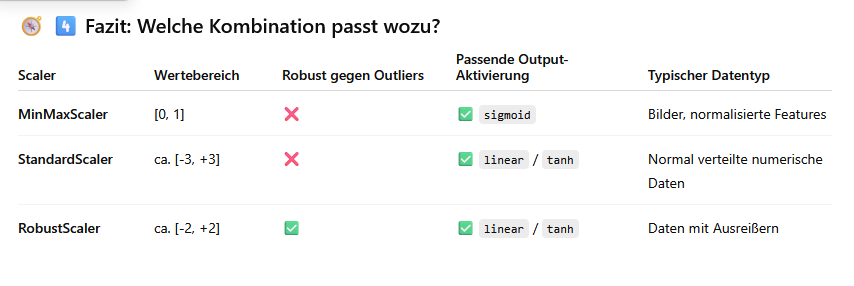


## 1.1  Datenvorbereitung: Simulationsdaten
### Summe von Verkäufen in DE, FR, US

   amount  tax  payment_terms country
0     980   19             30      DE
1    1200    7             60      FR
2     950   19             30      DE
3    2010    0              7      US
4     875   19             30      DE
5    1100    7             60      FR
6     970   19             30      DE
7    2000    0              7      US
data_augmented:
      amount  tax  payment_terms country
0       980   19             30      DE
1      1200    7             60      FR
2       950   19             30      DE
3      2010    0              7      US
4       875   19             30      DE
..      ...  ...            ...     ...
395     953   19             31      DE
396     957   17             27      DE
397    1056    7             60      FR
398     831   19             32      DE
399    1172    6             64      FR

[400 rows x 4 columns]


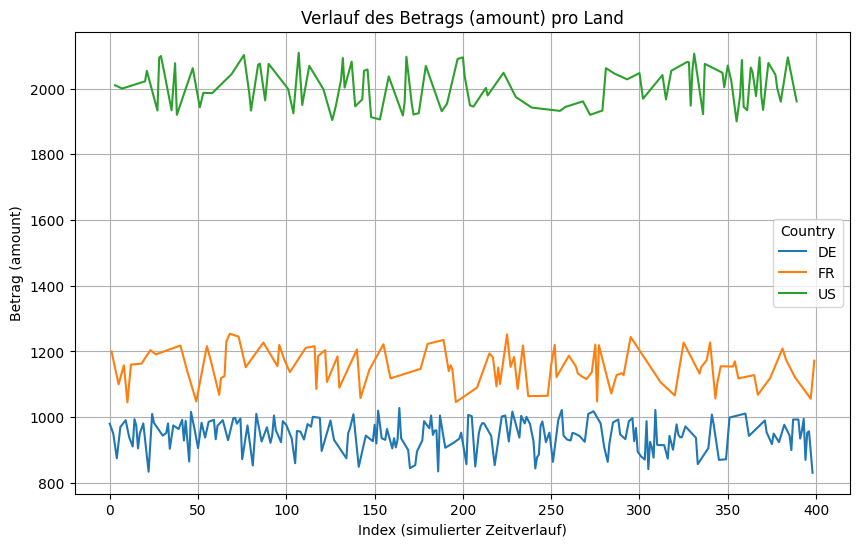

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
import random
import os

# 1️⃣ Allgemeine Seeds setzen
seed_value = 42
os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

# 2️⃣ TensorFlow deterministisch machen (optional, aber besser)
# verhindert, dass Operationen mit nicht-deterministischem Verhalten laufen
os.environ["TF_DETERMINISTIC_OPS"] = "1"


# Originaldaten: normale Daten
data = pd.DataFrame({
    "amount": [980, 1200, 950, 2010, 875, 1100, 970, 2000],
    "tax": [19, 7, 19, 0, 19, 7, 19, 0],
    "payment_terms": [30, 60, 30, 7, 30, 60, 30, 7],
    "country": ["DE", "FR", "DE", "US", "DE", "FR", "DE", "US"]
})

print(data)
print("====================")
# Anzahl gewünschter Zeilen
target_rows = 400 #150
current_rows = len(data)
rows_to_add = target_rows - current_rows

# Zufällige Auswahl der vorhandenen Zeilen + kleine Variationen
np.random.seed(42)
new_rows = []
for _ in range(rows_to_add):
    row = data.sample(1).iloc[0].copy()
    #print(type(row))
    # amount leicht variieren
    row["amount"] = int(row["amount"] * np.random.uniform(0.95, 1.05))
    # tax eventuell leicht anpassen
    if row["tax"] != 0:
        row["tax"] = int(row["tax"] * np.random.choice([1, 1.1, 0.9]))
    # payment_terms leicht variieren
    row["payment_terms"] = int(row["payment_terms"] * np.random.uniform(0.9, 1.1))
    new_rows.append(row)

# Neue Zeilen zum DataFrame hinzufügen
data_augmented = pd.concat([data, pd.DataFrame(new_rows)], ignore_index=True)

print("data_augmented:\n", data_augmented)
data= data_augmented
X= data_augmented

data_augmented.reset_index(inplace=True)  # Index als "Zeitachse" benutzen

# ======= Plot =======
plt.figure(figsize=(10, 6))
for country, subset in data_augmented.groupby("country"):
    plt.plot(subset["index"], subset["amount"], label=country)

plt.title("Verlauf des Betrags (amount) pro Land")
plt.xlabel("Index (simulierter Zeitverlauf)")
plt.ylabel("Betrag (amount)")
plt.legend(title="Country")
plt.grid(True)
plt.show()

# 2 train_test_split() + ColumnTransformer

In [2]:
from sklearn.model_selection import train_test_split

# 1. Train / Temp-Split (70% / 30%)
X_train, X_temp = train_test_split(X, test_size=0.3, random_state=42)

# 2. Temp-Split (Validation/Test = 15% / 15%)
X_val, X_test = train_test_split(X_temp, test_size=0.5, random_state=42)
df_X_test= X_test # Pandas Data Frame für Testausgabe

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)
print("X_test: data type:", type(X_test))
# Preprocessing mit handle_unknown="ignore"
num_features = ["amount", "tax", "payment_terms"]
cat_features = ["country"]

# MinMaxScaler : sigmoid
# RobustScaler, StandardScaler: linear
preprocessor = ColumnTransformer([
    ("num", RobustScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
])

X_train = preprocessor.fit_transform(X_train)
X_val = preprocessor.transform(X_val)
X_test = preprocessor.transform(X_test)

print(f"Trainingsdaten: {X_train.shape[0]} (DE & FR & US)")
print(f"Testdaten: {X_test.shape[0]} (DE & FR & US)")
#print(X_train)
print("==============: X_val")
#print(X_val)
print("==============: X_test")
print("X_test: data type:", type(X_test))
#print(X_test)
print("==============")





Train: (280, 5)
Val:   (60, 5)
Test:  (60, 5)
X_test: data type: <class 'pandas.core.frame.DataFrame'>
Trainingsdaten: 280 (DE & FR & US)
Testdaten: 60 (DE & FR & US)
==============: X_val
==============: X_test
X_test: data type: <class 'numpy.ndarray'>


# 3 Autoencoder-Modell in TensorFlow


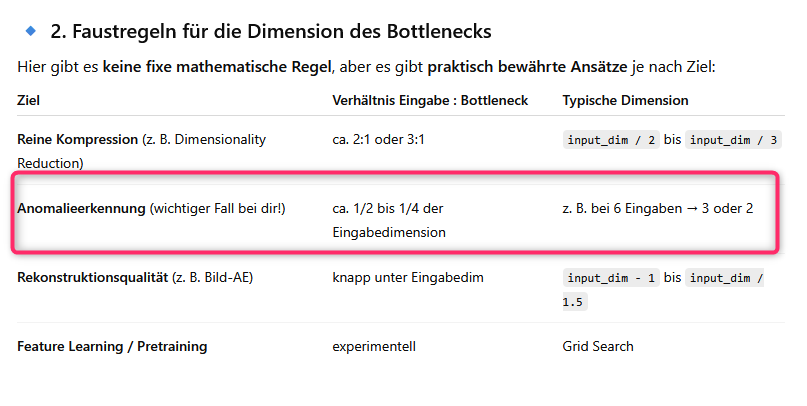


## 3.1 Training

input_dim: 6
Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2556 - val_loss: 0.1832
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1364 - val_loss: 0.0792
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0520 - val_loss: 0.0243
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0138 - val_loss: 0.0056
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0033 - val_loss: 0.0022
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0016 - val_loss: 0.0018
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0014 - val_loss: 0.0017
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0014 - val_loss: 0.0018
Epoch 9/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0014 - val_loss: 0.0017
Epoch 10/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0014 - val_loss: 0.0017
Epoch 11/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0014 - val_loss: 0.0017
Epoch 12/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,661 (6.49 KB)

 Trainable params: 553 (2.16 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,108 (4.33 KB)

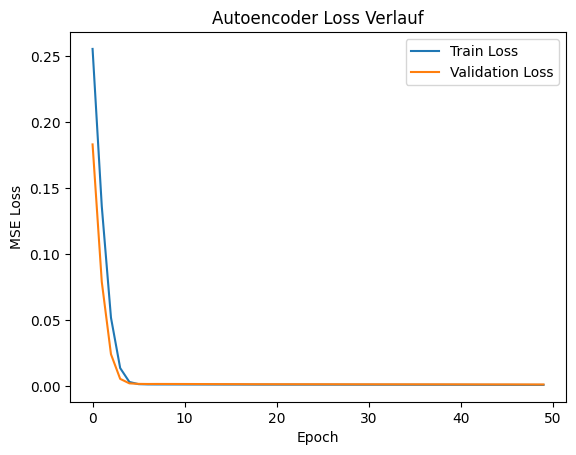

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models

input_dim = X_train.shape[1]
print("input_dim:", input_dim)
input_layer = layers.Input(shape=(input_dim,))
encoded = layers.Dense(16, activation="relu")(input_layer)
encoded1 = layers.Dense(8, activation="relu")(encoded)
bottleneck = layers.Dense(3, activation="relu")(encoded1) #bottleneck: dim=3, 4
decoded = layers.Dense(8, activation="relu")(bottleneck)
decoded1 = layers.Dense(16, activation="relu")(decoded)
# input_dim=6
# MinMaxScaler : sigmoid
# RobustScaler, StandardScaler: linear
#output_layer = layers.Dense(input_dim, activation="sigmoid")(decoded1)
output_layer = layers.Dense(input_dim, activation="linear")(decoded1)

autoencoder = models.Model(input_layer, output_layer)
autoencoder.compile(optimizer="adam", loss="mse")

history = autoencoder.fit(
    X_train, X_train,
    epochs=50,
    batch_size=4,
    validation_data=(X_val, X_val),
    #shuffle=False, 
    verbose=1
)

autoencoder.summary()


plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Autoencoder Loss Verlauf")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()


# 4 Reconstructions für X_test
- Threshold soll aus X_train berechnet werden. threshold_iqr = np.percentile(train_mse, 75) + 1.5 * iqr
- Threshold soll nicht aus X_test berechnet wird, denn:
  
 Der Threshold soll das „normale“ Rekonstruktionsverhalten abbilden — und das kennt man nur aus den Trainingsdaten.

## 4.1 predict(X_test)

In [4]:
import matplotlib.pyplot as plt
import numpy as np


print(" len of mse, X_test:", len(X_test) )
reconstructions = autoencoder.predict(X_test)
mse = np.mean(np.power(X_test - reconstructions, 2), axis=1)
print(" len of X_test:", len( mse), len(X_test) )
print("X_test: reconstructions.shape", reconstructions.shape)
print("mse-test", mse)

# Schwelle (z. B. 95. Perzentil aus Trainingsfehlern)
train_recons = autoencoder.predict(X_train)
train_mse = np.mean(np.power(X_train - train_recons, 2), axis=1)

#print("Threshold von percentile(95):", threshold)
# bessere  Threshold
q95 = np.percentile(train_mse, 95)
q75= np.percentile(train_mse, 75)
q25= np.percentile(train_mse, 25)
iqr = q75 - q25 
threshold_iqr = q75 + 1.5 * iqr  # q25, q75
# add a factor to increase robustness
#threshold_iqr= threshold_iqr + threshold_iqr*.1 # 10%
# threshold_std
mean = np.mean(train_mse)
std = np.std(train_mse)
threshold_std = mean + 3 * std  # 3 Sigma Regel
#============
threshold_90_iqr = np.percentile(train_mse, 90) + 0.5 * iqr


print("threshold_iqr aus X_train: q95, iqr, iqr + 1.5 * iqr, threshold_std, threshold_90_iqr:\n", q95, iqr, threshold_iqr, threshold_std, threshold_90_iqr)
# Ergebnisse
print("==============")
print("Test Daten: ")
print("Test threshold_iqr: ", threshold_iqr)
for i, (country, err) in enumerate(zip(df_X_test["country"], mse)):
    label = "🚨 Anomalie" if err > threshold_iqr else "✅ Normal"
    print(f"{i+1:2d}. {country:>3} - MSE={err:.5f} -> {label}")

print(df_X_test)



 len of mse, X_test: 60
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
 len of X_test: 60 60
X_test: reconstructions.shape (60, 6)
mse-test [8.24125266e-04 7.25521313e-04 1.16725631e-03 3.18000675e-04
 3.30146363e-04 2.00568466e-05 1.43500186e-03 4.58069780e-04
 3.10608944e-03 5.52854242e-04 2.63918369e-03 6.63641943e-04
 6.30514972e-04 2.93144509e-04 3.53881739e-04 3.58880023e-04
 1.75770057e-03 1.17984299e-04 1.06655311e-03 1.58995194e-03
 1.27218906e-04 2.25759098e-04 2.02090026e-03 2.17990771e-03
 7.22110552e-04 1.07338065e-03 3.10019440e-04 3.40128773e-04
 5.95634086e-04 5.30668451e-04 3.77973157e-04 2.50609730e-03
 4.24569904e-04 3.87138554e-04 1.56818420e-04 8.36457844e-05
 4.67844950e-04 5.65203686e-04 9.55366184e-04 1.21647549e-03
 1.06180565e-03 2.07517842e-03 4.91613479e-03 5.84853265e-04
 5.06560090e-04 9.34465830e-04 4.10676106e-04 1.31323736e-03
 1.36768931e-03 2.14156526e-03 4.02541809e-04 2.22283156e-03
 3.65877953e-04 8.33763477e-05 5.76628567e-04 2.96189756e-04
 4.03719496e-04

# 5 Anomalien erkennen

## 5.1 Originale Testdaten
data = pd.DataFrame({
 -   "amount": [980, 1200, 950, 2010, 875, 1100, 970, 2000],
 -   "tax": [19, 7, 19, 0, 19, 7, 19, 0],
 -   "payment_terms": [30, 60, 30, 7, 30, 60, 30, 7],
 -   "country": ["DE", "FR", "DE", "US", "DE", "FR", "DE", "US"]

## 5.2 Originale Daten -> finale Testdaten 
- FR: 1100 -> 3000 modifiziert
- DE: 5000 zugefügt 
- US: 45000 zugefügt

df_final_test = pd.DataFrame({

 -   "amount": [980, 1200, 950, **45000**, 875, **3000**, 970, 2000, **5000**],
 -   "tax": [19, 7, 19, 0, 19, 7, 19, 0,19],
 -  "payment_terms": [30, 60, 30, 7, 30, 60, 30, 7,30],
 -   "country": ["DE", "FR", "DE", "US", "DE", "FR", "DE", "US", "DE"]
})

## 5.3 reconstructions = autoencoder.predict(X_final_test)

   amount  tax  payment_terms country
0     980   19             30      DE
1    1200    7             60      FR
2     950   19             30      DE
3   10000    0              7      US
4     875   19             30      DE
5    3000    7             60      FR
6     970   19             30      DE
7    2000    0              7      US
8    5000   19             30      DE
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
mse-test [3.77973605e-04 1.30980153e-03 1.53911120e-04 6.83568879e+00
 4.55768170e-04 5.27140482e-01 2.81393549e-04 1.77331554e-05
 2.07953902e+00]
 1.  DE - MSE=0.00038 -> ✅ Normal
 2.  FR - MSE=0.00131 -> ✅ Normal
 3.  DE - MSE=0.00015 -> ✅ Normal
 4.  US - MSE=6.83569 -> 🚨 Anomalie
 5.  DE - MSE=0.00046 -> ✅ Normal
 6.  FR - MSE=0.52714 -> 🚨 Anomalie
 7.  DE - MSE=0.00028 -> ✅ Normal
 8.  US - MSE=0.00002 -> ✅ Normal
 9.  DE - MSE=2.07954 -> 🚨 Anomalie


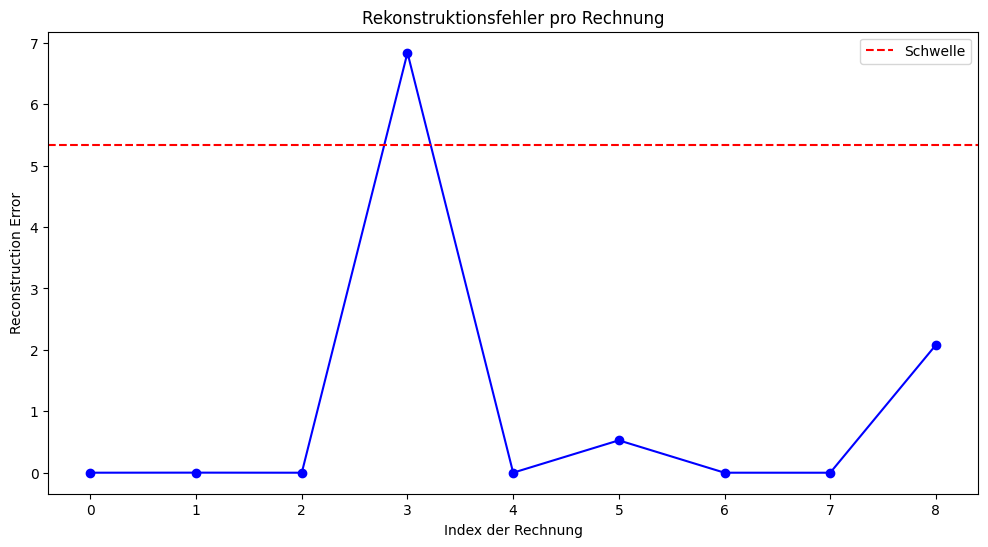

   amount  tax  payment_terms country  reconstruction_error
3   10000    0              7      US              6.835689
8    5000   19             30      DE              2.079539
5    3000    7             60      FR              0.527140
1    1200    7             60      FR              0.001310
4     875   19             30      DE              0.000456
0     980   19             30      DE              0.000378
6     970   19             30      DE              0.000281
2     950   19             30      DE              0.000154
7    2000    0              7      US              0.000018


In [5]:
df_final_test = pd.DataFrame({

   "amount": [980, 1200, 950, 10000, 875, 3000, 970, 2000, 5000],
   "tax": [19, 7, 19, 0, 19, 7, 19, 0,19],
   "payment_terms": [30, 60, 30, 7, 30, 60, 30, 7,30],
   "country": ["DE", "FR", "DE", "US", "DE", "FR", "DE", "US", "DE"]
})

#X_test = preprocessor.transform(df_data_test)
X_final_test = preprocessor.transform(df_final_test)

print( df_final_test.head(15))

reconstructions = autoencoder.predict(X_final_test)
reconstruction_error = np.mean(np.power(X_final_test - reconstructions, 2), axis=1)
print("mse-test", reconstruction_error)

# Ergebnisse
# for i, (country, err) in enumerate(zip(df_X_test["country"], reconstruction_error)):
for i, (country, err) in enumerate(zip(df_final_test["country"], reconstruction_error)):
    label = "🚨 Anomalie" if err > threshold_iqr else "✅ Normal"
    print(f"{i+1:2d}. {country:>3} - MSE={err:.5f} -> {label}")



#X_pred = autoencoder.predict(X_test)
#reconstruction_error = np.mean(np.square(X_test - X_pred), axis=1)

# 6️⃣ Fehler im DataFrame hinzufügen
df_final_test ["reconstruction_error"] = reconstruction_error #  reconstruction_error

# 7️⃣ Schwellenwert setzen (z.B. Mittelwert + 2*Std)
threshold_mse = reconstruction_error.mean() + 2 * reconstruction_error.std()

# 8️⃣ Plot
plt.figure(figsize=(12,6))
plt.plot(df_final_test.index, df_final_test["reconstruction_error"], "bo-")
plt.axhline(threshold_mse, color="red", linestyle="--", label="Schwelle")
plt.title("Rekonstruktionsfehler pro Rechnung")
plt.xlabel("Index der Rechnung")
plt.ylabel("Reconstruction Error")
plt.legend()
plt.show()

# 9️⃣ Sortierte Ansicht
data_sorted = df_final_test.sort_values("reconstruction_error", ascending=False)
print(data_sorted)



